This project focuses on building and evaluating machine learning models to predict house prices based on various property features. The goal is to understand how different regression algorithms perform on structured housing data and to identify the most effective model for accurate price prediction.


The project follows a structured pipeline:

Data exploration and cleaning
Feature encoding and scaling
Train-test split
Baseline model (Linear Regression)
Advanced models (Decision Tree, Random Forest, Gradient Boosting)
Model evaluation and comparison
Hyperparameter tuning using GridSearchCV
Feature importance analysis
Final model selection and interpretation

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV


In [2]:
# Load Dataset
Housing = pd.read_csv("Cleaned_Housing.csv")

Explore Dataset

In [3]:
# Display first 10 rows to confirm data loaded correctly and get a quick look at the variables
Housing.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# Check dataset shape(number of rows and columns in the dataset)
Housing.shape

(545, 13)

In [5]:
# check for data types
Housing.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [6]:
# Check for nulls
Housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
# Check for duplicates
Housing.duplicated().sum()

np.int64(0)

In [8]:
# Summary statistics-numerical columns
Housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


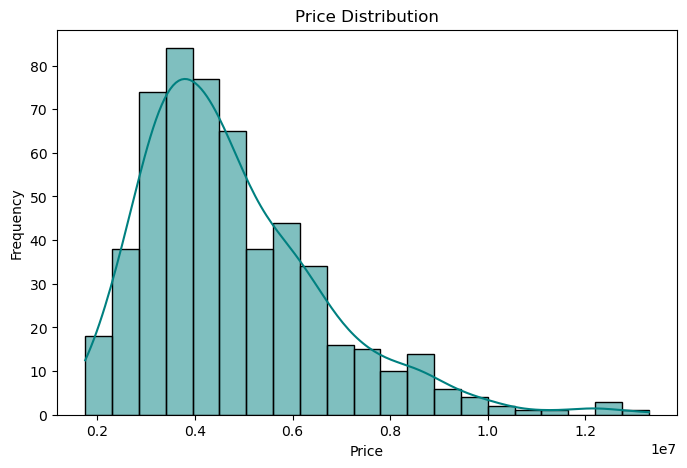

In [9]:
# Target variable The target variable is price, which represents the selling price of each house
# Visualisation of distribution for price-target
plt.figure(figsize=(8,5))
sns.histplot(data=Housing,x="price",kde= True, color="teal")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

The distribution of house prices is positively skewed, with most properties concentrated in the lower to mid-price range.
A small number of high-priced houses create a long right tail, causing the mean house price to be greater than the median.

Data Preprocessing

In [10]:
# Encode categorical variables-Binary
Binary = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
mapping_list = {"yes":1,
                "no":0}
for i in Binary:
    Housing[i]=Housing[i].map(mapping_list)


In [11]:
#Encode non-binary column(furnishingstatus) using one-hot encoding
Housing = pd.get_dummies(Housing,columns=["furnishingstatus"], drop_first=True,dtype=int)

In [12]:
# check to confirm categorical columns are properly encoded
Housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [13]:
# Separate data into Features(X) and Target(y)
y= Housing["price"]
X= Housing.drop(columns=["price"])

In [14]:
#Split data into train and test sets
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
#selecting numerical columns to scale
numerical_columns = ["area","bedrooms","bathrooms","stories","parking"]

In [16]:
#Scaler selection
scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [17]:
# confirmation
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,0.384168,0.055271,1.539173,2.587644,1,0,0,0,1,0.367957,0,0,0
93,0.929181,0.055271,1.539173,-0.912499,1,0,1,0,1,2.709987,0,1,0
335,-0.607755,-1.283514,-0.557950,-0.912499,1,0,1,0,1,1.538972,0,0,0
412,-1.155492,0.055271,-0.557950,0.254215,1,0,1,0,0,-0.803059,1,0,1
471,-0.637730,0.055271,-0.557950,0.254215,1,0,0,0,0,-0.803059,0,0,1


In [18]:
# create empty lists to store results for evaluation metrics to be converted into dataframes 
R2_scores = []
Metrics_results = []

In [19]:
 # Baseline Model (Linear Regression)
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_predicted = model.predict(X_test)
y_predicted

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.3272256 , 3294646.25725956, 3532275.09556558,
       5611774.56836474, 6368145.98732718, 2722856.95689986,
       2629405.61585783, 9617039.50315578, 2798087.30447888,
       3171096.76847064, 3394639.09125529, 3681088.65424276,
       5263187.74621486, 3035963.47612386, 4786122.8004005 ,
       4349551.9200572 , 3572362.09930451, 5774875.2139565 ,
       5886993.57919883, 2730836.19518458, 4727316.47323636,
       5244847.52716799, 7555324.21605601, 3220790.84680269,
       5191898.79934207, 8143726.91009782, 3398814.09825036,
       6490693.05027926, 3315105.90747811, 6708457.36761325,
       4201738.21071676, 3557571.06735186, 5836974.50478626,
       4808660.67448475, 4362878.73613262, 3191242.95701508,
       4596554.93225239, 4566042.8604841 , 3517779.52374149,
       7205844.79365835, 3983597.27861103, 3749338.70271055,
       4274731.09125895, 6757442.10783741, 4037320.43665851,
       3769334.90397125,

In [21]:
#evaluate model performance
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
rmse = np.sqrt(mse)

In [22]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

R2_scores.append({"Model": "Linear Regression",
                  "Train_score": train_r2,
                  "Test_score": test_r2})

# print(f"Training R²: {train_r2:.3f}")
# print(f"Testing R²: {test_r2:.3f}")

In [23]:
Metrics_results.append({
    "Model": "Linear Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R²": r2
})

In [24]:
 # Advanced Models
# Decision Tree
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [25]:
y_pred = model.predict(X_test)
y_pred

array([ 5600000.,  7840000.,  3850000.,  4935000.,  2660000.,  2730000.,
        6090000.,  4893000.,  2100000.,  2940000., 12250000.,  2957500.,
        3255000.,  3703000.,  2730000.,  3885000.,  3447500.,  4270000.,
        3640000.,  3710000.,  6160000.,  5950000.,  2957500.,  3633000.,
        6020000.,  6790000.,  3150000.,  4200000.,  7000000.,  2961000.,
        6615000.,  2100000.,  6195000.,  4235000.,  2485000.,  6405000.,
        4900000.,  4200000.,  3115000.,  3885000.,  3773000.,  2870000.,
        7840000.,  4480000.,  4270000.,  4200000.,  7560000.,  4480000.,
        3087000.,  3430000.,  8960000.,  1855000.,  3500000.,  4900000.,
        3500000.,  2940000.,  8295000.,  2100000.,  5040000.,  2957500.,
        3815000.,  3920000.,  4900000.,  4620000.,  3780000.,  4480000.,
        5950000.,  2450000.,  4795000.,  3395000.,  4200000.,  5873000.,
        8400000.,  7245000.,  3290000.,  4025000.,  4480000.,  3010000.,
        3710000.,  5600000.,  8540000.,  4480000., 

In [26]:
#Evaluate model
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
rmse= np.sqrt(mse)

In [27]:

train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

R2_scores.append({"Model": "Decision Tree Regressor",
                  "Train_score": train_r2,
                  "Test_score": test_r2})
# print(f"Training R²: {train_r2:.3f}")
# print(f"Testing R²: {test_r2:.3f}")

In [28]:
Metrics_results.append({
    "Model": "DecisionTreeRegressor",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R²": r2
})

In [29]:
# Randomforest
model = RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_predict = model.predict(X_test)
y_predict

array([5351080.        , 7270270.        , 3761878.75      ,
       4509890.        , 3751650.        , 3440360.        ,
       5092920.        , 5046230.        , 2575090.        ,
       2873276.        , 9952209.4       , 3358490.        ,
       3027966.66666667, 3457650.        , 3556070.        ,
       3929660.        , 3329340.        , 4868885.        ,
       3673530.        , 4074945.        , 5451985.        ,
       5932920.        , 3068636.66666667, 3661980.        ,
       4721920.        , 6527325.        , 3094840.        ,
       4599910.        , 6329540.        , 3244570.        ,
       5757780.        , 3189690.        , 6730220.        ,
       4362890.        , 2942100.        , 6329050.        ,
       4868290.        , 3690680.        , 3102960.        ,
       4153310.        , 4142250.        , 2867865.        ,
       7436940.        , 4193910.        , 4001900.        ,
       4326770.        , 7299320.        , 4102840.        ,
       2992850.        ,

In [31]:
# Evaluate Randonforest model
mae = mean_absolute_error(y_test,y_predict)
mse = mean_squared_error(y_test,y_predict)
r2 = r2_score(y_test, y_predict)
rmse = np.sqrt(mse)

In [32]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

R2_scores.append({"Model": "Random Forest",
                  "Train_score": train_r2,
                  "Test_score": test_r2})

# print(f"Training R²: {train_r2:.3f}")
# print(f"Testing R²: {test_r2:.3f}")

In [33]:
Metrics_results.append({
    "Model": "RandomForestRegressor",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R²": r2
})

In [34]:
# GradientBoostingRegressor
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [35]:
y_pre = gb_model.predict(X_test)
y_pre

array([ 4486984.35601967,  7208750.95765462,  3693243.50703918,
        4439761.73364167,  3739117.80400389,  3908167.73490597,
        6154987.05709327,  5864341.77465772,  3140942.70728673,
        3094515.49493127, 11976314.95867104,  2889030.56079701,
        3207415.30989852,  3530460.79388718,  3509500.64128847,
        3977763.78540773,  3079800.14215291,  5462042.12492552,
        4426184.13160516,  4342926.62765164,  5699928.52082062,
        5978203.19714682,  2889030.56079701,  4323509.81559808,
        4679964.32364597,  6693092.6204141 ,  3596527.30137992,
        4696771.62160613,  7221539.2436918 ,  3354375.37751221,
        5620189.66886243,  3375465.94380825,  6734193.78237649,
        4389227.35785899,  3438069.00392726,  6354624.09850798,
        4812771.99055805,  3801621.43194576,  2867183.64513333,
        4131790.10899062,  4589475.45334774,  3091373.41653655,
        7208750.95765462,  4319711.2898231 ,  4025800.97397459,
        4032750.23379889,  7139723.17257

In [36]:
# Evaluate GradientBoostingRegressor
mae = mean_absolute_error(y_test,y_pre)
mse = mean_squared_error(y_test,y_pre)
r2 = r2_score(y_test, y_pre)
rmse = np.sqrt(mse)

In [37]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

R2_scores.append({"Model": "Gradient Boosting Regressor",
                  "Train_score": train_r2,
                  "Test_score": test_r2})

# print(f"Training R²: {train_r2:.3f}")
# print(f"Testing R²: {test_r2:.3f}")

In [38]:
Metrics_results.append({
    "Model": "GradientBoostingRegressor",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R²": r2
})

In [39]:
comparison_table = pd.DataFrame(Metrics_results)
comparison_table

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,DecisionTreeRegressor,1.195266e+06,2.642803e+12,1.625670e+06,0.477146
2,RandomForestRegressor,1.022197e+06,1.961944e+12,1.400694e+06,0.611848
3,GradientBoostingRegressor,9.605788e+05,1.689379e+12,1.299761e+06,0.665772


In [40]:
R2_Table = pd.DataFrame(R2_scores)
R2_Table

,Model,Train_score,Test_score
0,Linear Regression,0.685944,0.652924
1,Decision Tree Regressor,0.998540,0.477146
2,Random Forest,0.949919,0.611848
3,Gradient Boosting Regressor,0.949919,0.611848


R² Score Comparison Across Models
The plot below visually compares the R² scores of the different models on the test set, allowing for a quick assessment of their predictive performance.

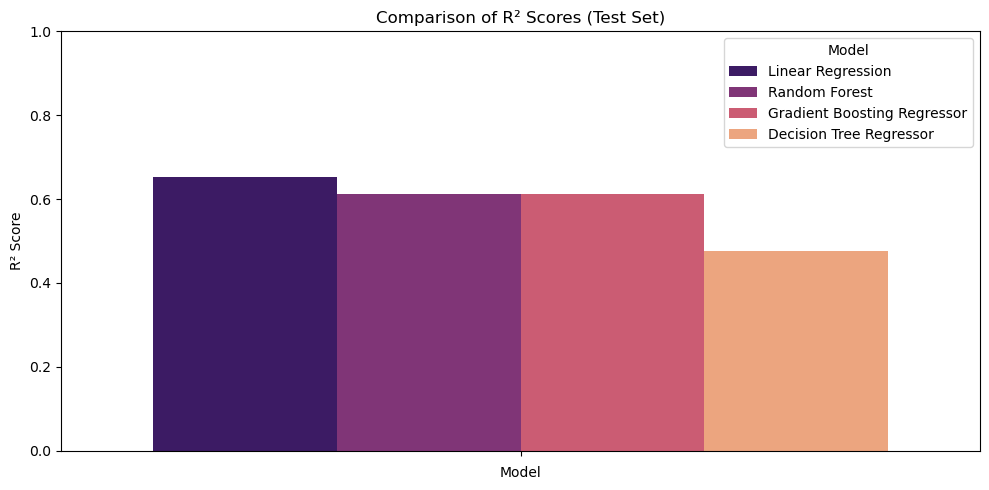

In [41]:
plt.figure(figsize=(10, 5))
sns.barplot(hue='Model', y='Test_score', data=R2_Table.sort_values(by='Test_score', ascending=False), palette='magma',legend=True)
plt.title('Comparison of R² Scores (Test Set)')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 1) # R² scores are typically between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Hyperparameter Tuning

The Random Forest model exhibited signs of overfitting, achieving a training R² of 0.950 but only 0.612 on the test set. Therefore, hyperparameter tuning is performed to reduce model complexity and improve generalization.

Parameters to tune n_estimators #Number of trees in the forest. max_depth #Maximum depth of each tree. min_samples_split #number of samples required before a node can split min_samples_leaf #Minimum samples allowed in a leaf node.

In [42]:
param_grid= {"n_estimators": [100,200],
           "max_depth": [5,10,None],
           "min_samples_split": [2,5,10],
           "min_samples_leaf": [1,2,4]}

 

In [43]:

model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=model,
                           param_grid= param_grid,
                           scoring ="r2",
                           cv=5,
                           n_jobs=-1)
                           

In [44]:
grid_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [45]:
grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 100}

In [46]:
best_model = grid_search.best_estimator_

In [47]:
#predict using the best model
y_best = best_model.predict(X_test)

# Evaluate Tuned Random Forest Regressor
best_mae = mean_absolute_error(y_test,y_best)
best_mse = mean_squared_error(y_test,y_best)
best_r2 = r2_score(y_test, y_best)
best_rmse = np.sqrt(best_mse)

In [48]:
Metrics_results.append({
    "Model": "Tuned Random Forest",
    "MAE": best_mae,
    "MSE": best_mse,
    "RMSE": best_rmse,
    "R²": best_r2
})

In [49]:
comparison_df = pd.DataFrame(Metrics_results)
comparison_df

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,DecisionTreeRegressor,1.195266e+06,2.642803e+12,1.625670e+06,0.477146
2,RandomForestRegressor,1.022197e+06,1.961944e+12,1.400694e+06,0.611848
3,GradientBoostingRegressor,9.605788e+05,1.689379e+12,1.299761e+06,0.665772
4,Tuned Random Forest,1.056459e+06,2.104685e+12,1.450753e+06,0.583608


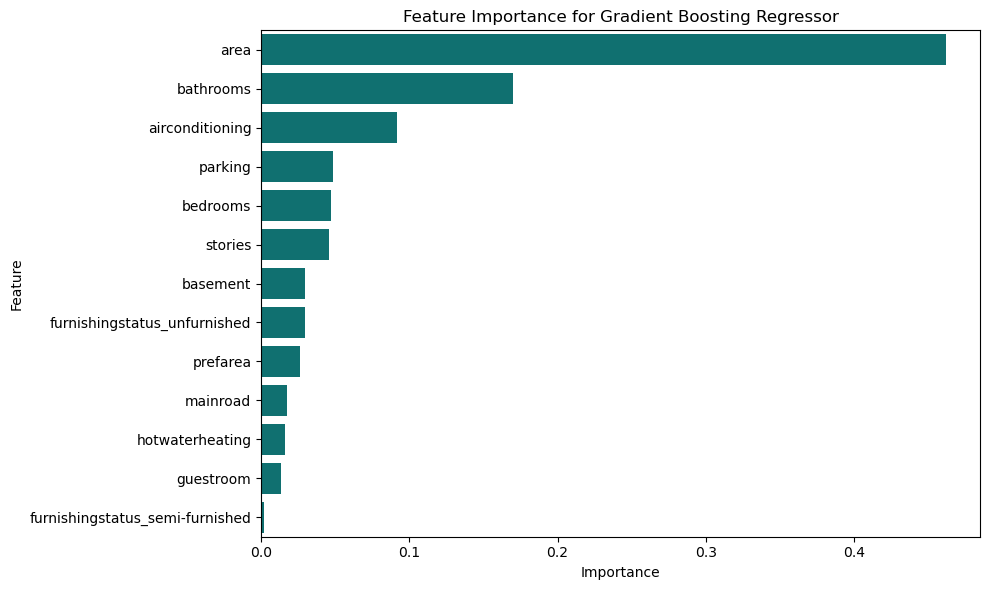

In [50]:
#plot feature importance to determine Which features the model relied on most.
features = X_train.columns
feature_importances = gb_model.feature_importances_ 

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df,color="teal")
plt.title('Feature Importance for Gradient Boosting Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The feature importance plot shows that area was the most influential predictor of house price, contributing substantially more than any other feature. Bathrooms and air conditioning were also important predictors, while variables such as guest room and hot water heating had relatively little influence on the model's predictions.

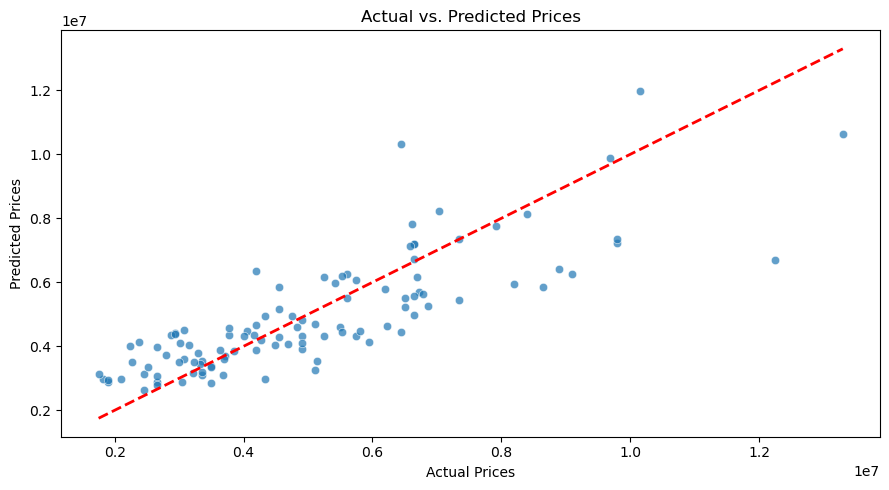

In [51]:
# plot actual price vs predicted prives by Gradient Boosting model
plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_test, y=y_pre, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.tight_layout()
plt.show()

Conclusion

This project aimed to predict house prices using various machine learning models and improve their performance through hyperparameter tuning. After comprehensive data preparation, including handling categorical variables and feature scaling, several regression models were trained and evaluated:

Linear Regression (Baseline): Served as a fundamental benchmark.
Decision Tree Regressor:Showed high training accuracy but significant overfitting.
Random Forest Regressor:Improved upon the Decision Tree, reducing overfitting.
Gradient Boosting Regressor:Demonstrated the best performance among the untuned models.
Tuned Random Forest Regressor: Hyperparameter tuning was applied to the Random Forest model to optimize its generalization capabilities.

The Gradient Boosting Regressor emerged as the best-performing model in terms of R² score on the test set, achieving an R² of approximately 0.666. While hyperparameter tuning on the Random Forest model did improve its test R² compared to its untuned counterpart, it did not surpass the Gradient Boosting model in this instance. The feature importance analysis for the best model indicated that `area` was by far the most significant predictor of house price, followed by `bathrooms` and `airconditioning`.

Key Findings:
1.  The dataset, while clean, exhibited a positive skew in house prices, which was handled appropriately by the models.
2.  Ensemble methods (Random Forest and Gradient Boosting) consistently outperformed the simpler Linear Regression and single Decision Tree models.
3.  Gradient Boosting provided the strongest predictive power for this dataset, achieving the highest R² on unseen data.
4.  Hyperparameter tuning is crucial for optimizing model performance and reducing overfitting, though its impact can vary, as seen with the Tuned Random Forest not outperforming Gradient Boosting.
5.  `area` is the dominant feature in determining house prices.

Future Work:
Explore more advanced ensemble techniques like XGBoost or LightGBM.
Investigate feature engineering opportunities, such as creating interaction terms or polynomial features.
Consider robust outlier detection and handling methods, especially given the skewed price distribution.
Gather more data, if possible, to potentially improve model generalization further.